In [143]:
#install.packages("remotes")
#remotes::install_github("GotelliLab/EcoSimR")

In [144]:
library(EcoSimR)
library(cooccur)
library(ggplot2)

# Demo on built in dataset

                         Seymour Baltra Isabella Fernandina Santiago
Geospiza magnirostris          0      0        1          1        1
Geospiza fortis                1      1        1          1        1
Geospiza fuliginosa            1      1        1          1        1
Geospiza difficilis            0      0        1          1        1
Geospiza scandens              1      1        1          0        1
Geospiza conirostris           0      0        0          0        0
Camarhynchus psittacula        0      0        1          1        1
Camarhynchus pauper            0      0        0          0        0
Camarhynchus parvulus          0      0        1          1        1
Platyspiza crassirostris       0      0        1          1        1


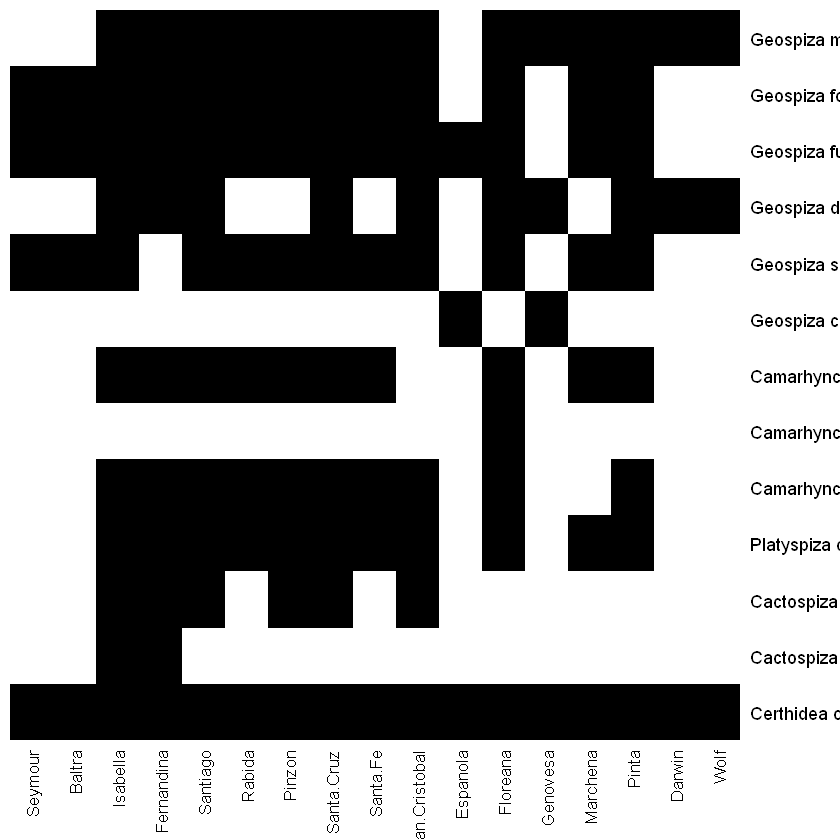

In [145]:
data(finches)
df <- finches

print(df[1:10, 1:5])

heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
        Rowv = NA, Colv = NA)

In [146]:
cat("Species:", nrow(df), "\n")
cat("Sites:", ncol(df), "\n")
cat("Total presences:", sum(df), "\n")
cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)    # occurrences per species
sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)    # richness per site
c_score(as.matrix(df))

Species: 13 
Sites: 17 
Total presences: 122 
Fill percent: 0.55 


Certhidea olivacea    Geospiza magnirostris      Geospiza fuliginosa 
                   1.000                    0.824                    0.824 
         Geospiza fortis        Geospiza scandens Platyspiza crassirostris 
                   0.765                    0.706                    0.647 
     Geospiza difficilis  Camarhynchus psittacula    Camarhynchus parvulus 
                   0.588                    0.588                    0.588 
      Cactospiza pallida     Geospiza conirostris    Cactospiza heliobates 
                   0.353                    0.118                    0.118 
     Camarhynchus pauper 
                   0.059

Isabella    Fernandina      Santiago    Santa.Cruz      Floreana 
        0.846         0.769         0.769         0.769         0.769 
       Pinzon San.Cristobal         Pinta        Rabida      Santa.Fe 
        0.692         0.692         0.692         0.615         0.615 
     Marchena       Seymour        Baltra      Genovesa      Espanola 
        0.538         0.308         0.308         0.308         0.231 
       Darwin          Wolf 
        0.231         0.231

[1] 4.269231

Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:41:06 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  3.7 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  4.2692 
Mean Of Simulated Index:  3.1335 
Variance Of Simulated Index:  0.037057 
Lower 95% (1-tail):  2.8846 
Upper 95% (1-tail):  3.5256 
Lower 95% (2-tail):  2.8462 
Upper 95% (2-tail):  3.6026 
Lower-tail P >  0.9998 
Upper-tail P <  2e-04 
Observed metric > 5000 simulated metrics 
Observed metric < 0 simulated metrics 
Observed metric = 0 simulated metrics 
Standardized Effect Size (SES):  5.8999 


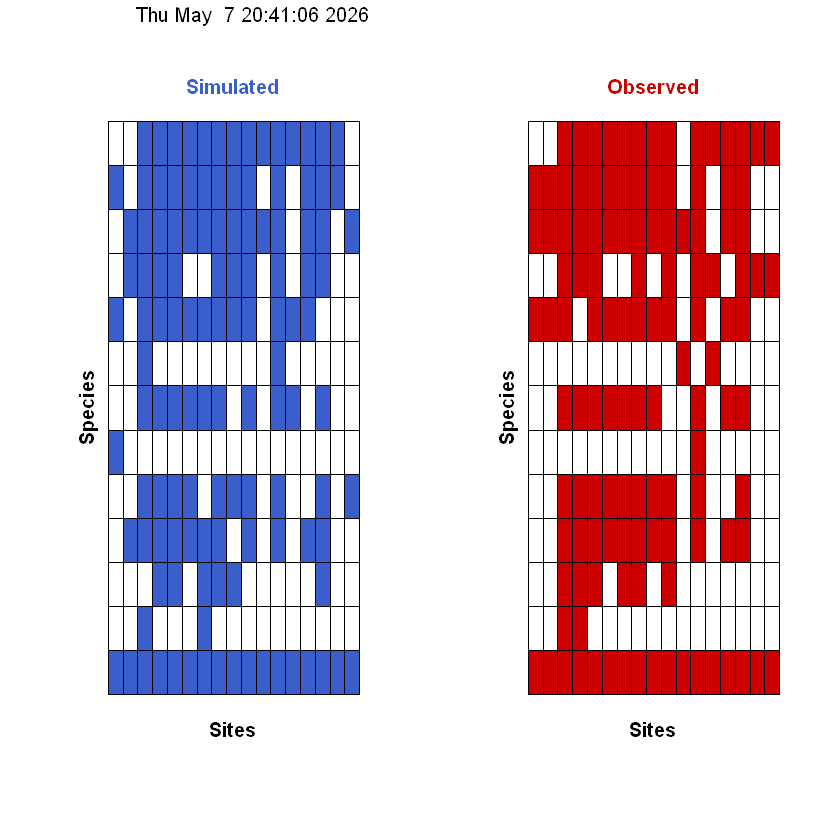

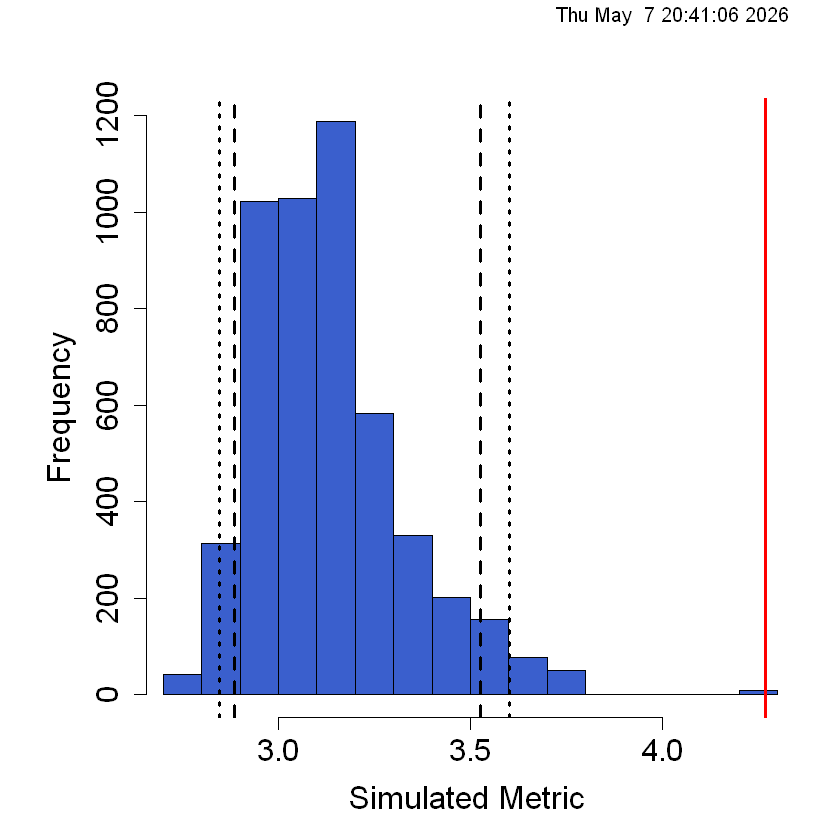

In [147]:
############################
# cooccurence null model
############################
df_cooc <- cbind(ID = rownames(df), df)
rownames(df_cooc) <- NULL
nullMod <- cooc_null_model(df_cooc, algo = "sim9",  burn_in = 50000, nReps = 5000)
summary(nullMod)
plot(nullMod, type = "cooc")
plot(nullMod, type = "hist")

## Results: Sanderson (2000) Finches — Demo Dataset

**Significant checkerboard structure detected** — species co-occur less than expected by chance.

| Metric | Value |
|---|---|
| Observed C-score | 4.XX |
| Mean simulated | 3.130 |
| SES | 6.XX |
| P-value (upper-tail) | < 0.0001 |

- Observed C-score exceeded all 10,000 null model replicates (sim9)
- 13 species × 17 islands

**Interpretation:** Finch species are significantly segregated across the 17 sites, consistent with competitive exclusion or island-level habitat partitioning. 

In [148]:
cooc_data <- "pres_abs_stratum.csv"
#cooc_data <- "pres_abs_lcode.csv"
df <- read.csv(cooc_data, header=TRUE)
df_richness <- df[c(-1,-2),-1]
df_richness[] <- lapply(df_richness, function(x) as.numeric(as.character(x)))
t(t(sort(colSums(df_richness), decreasing=TRUE)[1:10]))
t(t(sort(colSums(df_richness), decreasing=FALSE)[1:10]))

BWC.S_2013_LG,44
SCB_2013_LG,42
BWC.S_2015_LG,42
BWC.S_2018_LG,42
BWC.S_2020_LG,42
BWC.S_2024_LG,42
BWC.S_2003_LG,41
BWC.S_2017_LG,41
SCB_2021_LG,41
BWC.S_2010_LG,40


MCB.W_1995_26,8
MCB.W_1998_26,10
MCB.W_1994_26,11
MCB.W_2018_26,11
TWZ_2023_LG,11
MCB.W_1996_26,12
MCB.W_2002_26,13
MCB.W_2004_26,13
IMP.S_2016_26,13
MCB.W_2016_26,13


# Ecosim Routines

In [149]:
run_ecosim <- function(pool="both", breakpoint="<=2007", nReps=10000, burn_in=25000) {
    
    ############################
    # load data
    ############################
    df <- read.csv(cooc_data, header=TRUE)
    if (pool != "both") {
        ind <- which(df[1,] == pool)
        df <- df[,c(1,ind)]
    }
    df <- df[-1,] # drop pool row

    # year breakpoint
    if (breakpoint == "<=2007") {
        ind <- which(df[1,2:ncol(df)] <= 2007)+1 # before breakpoint
    } else {
        ind <- which(df[1,2:ncol(df)] > 2007)+1 # after breakpoint
    }
    df <- df[,c(1,ind)]
    df <- df[2:nrow(df), ]
    rownames(df) <- df[,1]  
    df <- df[, -1]

    df[] <- lapply(df, function(x) as.numeric(as.character(x)))

    df <- df[rowSums(df) > 0, ] # remove species with no occurrences
    print(dim(df))
    print(df[1:5, 1:5])

    ############################
    # viz cooccurence matrix
    ############################

    heatmap(as.matrix(df)[nrow(df):1, ], col = c("white", "black"), scale = "none",
            Rowv = NA, Colv = NA, cexRow = 0.5, cexCol = 0.6)

    ############################
    # summary stats
    ############################
    cat("Species:", nrow(df), "\n")
    cat("Sites:", ncol(df), "\n")
    cat("Total presences:", sum(df), "\n")
    cat("Fill percent:", round(sum(df)/(nrow(df)*ncol(df)),2), "\n")
    sort(round(rowSums(df)/ncol(df),3), decreasing=TRUE)[1:5]    # occurrences per species
    sort(round(colSums(df)/nrow(df),3), decreasing=TRUE)[1:5]    # richness per site
    c_score(as.matrix(df))

    ############################
    # cooccurence null model
    ############################
    df_cooc <- cbind(ID = rownames(df), df)
    rownames(df_cooc) <- NULL
    nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = nReps,  burn_in = burn_in)
    summary(nullMod)
    #plot(nullMod, type = "cooc")
    plot(nullMod, type = "hist")
}

In [150]:
run_yearly_ecosim <- function(pool="both", years, nReps=10000, burn_in=25000) {
    
    ############################
    # load data
    ############################
    df <- read.csv(cooc_data, header=TRUE)
    if (pool != "both") {
        ind <- which(df[1,] == pool)
        df <- df[,c(1,ind)]
    }
    df <- df[-1,] # drop pool row

    # year breakpoint
    ind <- which(is.element(df[1,2:ncol(df)],years))+1 # before breakpoint
    
    df <- df[,c(1,ind)]
    df <- df[2:nrow(df), ]
    rownames(df) <- df[,1]  
    df <- df[, -1]

    df[] <- lapply(df, function(x) as.numeric(as.character(x)))

    df <- df[rowSums(df) > 0, ] # remove species with no occurrences
    
    ############################
    # cooccurence null model
    ############################
    df_cooc <- cbind(ID = rownames(df), df)
    rownames(df_cooc) <- NULL
    nullMod <- cooc_null_model(df_cooc, algo = "sim9", nReps = nReps,  burn_in = burn_in)
    return(nullMod)
}

In [151]:

run_ecosim_loop <- function(pool="both", year_chunks, nReps=10000, burn_in=25000) {
    results_df <- data.frame()

    for (ys in year_chunks) {
    print(paste("Running years:", paste(min(ys), max(ys), sep = "-")))
    null_mod <- run_yearly_ecosim(pool=pool, years = ys, nReps=nReps, burn_in=burn_in)

    ses_val <- (null_mod$Obs - mean(null_mod$Sim)) / sd(null_mod$Sim)
    obs_val <- null_mod$Obs
    exp_val <- mean(null_mod$Sim)
    sd_val  <- sd(null_mod$Sim)

    results_df <- rbind(
        results_df,
        data.frame(
        year = if (length(ys) == 1) {
            as.character(ys)
            } else {
            paste(min(ys), max(ys), sep = "-")
            },
        SES = ses_val,
        obs = obs_val,
        exp = exp_val,
        sd  = sd_val
        )
    )
    }

    # Ensure chronological order for chunk labels
    results_df$year <- factor(results_df$year, levels = results_df$year, ordered = TRUE)

    # SES plot
    p <- ggplot(results_df, aes(year, SES, group = 1)) +
    geom_hline(yintercept = 0, linetype = "dashed", linewidth = 1.2) +
    geom_hline(yintercept = c(-2, 2),
                linetype = "dotted",
                color = "red", linewidth = 1.2) +
    geom_line(linewidth = 1.2, color = "blue") +
    geom_point(size = 3, color = "blue") +
    theme_bw(base_size = 14) +
    theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5)
    ) +
    labs(
        title = "Fish community co-occurrence structure (SES)",
        x = "Year",
        y = "SES"
    )

    print(p)


    # Observed vs expected plot
    #q <- ggplot(results_df, aes(year, group = 1)) +
    #geom_ribbon(aes(ymin = exp - sd,
    #                ymax = exp + sd),
    #            fill = "gray70",
    #            alpha = 0.4) +
    #geom_line(aes(y = exp),
    #            linetype = "dashed",
    #            linewidth = 1,
    #            color = "red") +
    #geom_line(aes(y = obs),
    #            linewidth = 1.2,
    #            color = "black") +
    #geom_point(aes(y = obs),
    #            size = 2.5,
    #            color = "black") +
    #theme_bw(base_size = 14) +
    #theme(
    #    axis.text.x = element_text(angle = 90, vjust = 0.5)
    #) +
    #labs(
    #    title = "Observed vs Null C-score dynamics",
    #    x = "Year",
    #    y = "C-score"
    #)

    #print(q)

    #print(results_df)
}

# Combined pools

## <= 2007

[1]  60 134
     BWC.S_1993_26 IMP.S_1993_26 MCB.U_1993_26 SCB_1993_26 BWC.S_1994_26
BHCP             0             0             0           0             0
BHMW             0             0             1           1             1
BKBF             0             0             1           1             1
BKCP             1             1             1           0             1
BKSS             0             1             1           1             0
Species: 60 
Sites: 134 
Total presences: 3340 
Fill percent: 0.42 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:41:22 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  16 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  306.06 
Mean Of Simulated Index:  300.79 
Variance Of Simulated Index:  0.63193 
Lower 95% (1-tail):  299.67 
Upper 95% (1-tail):  

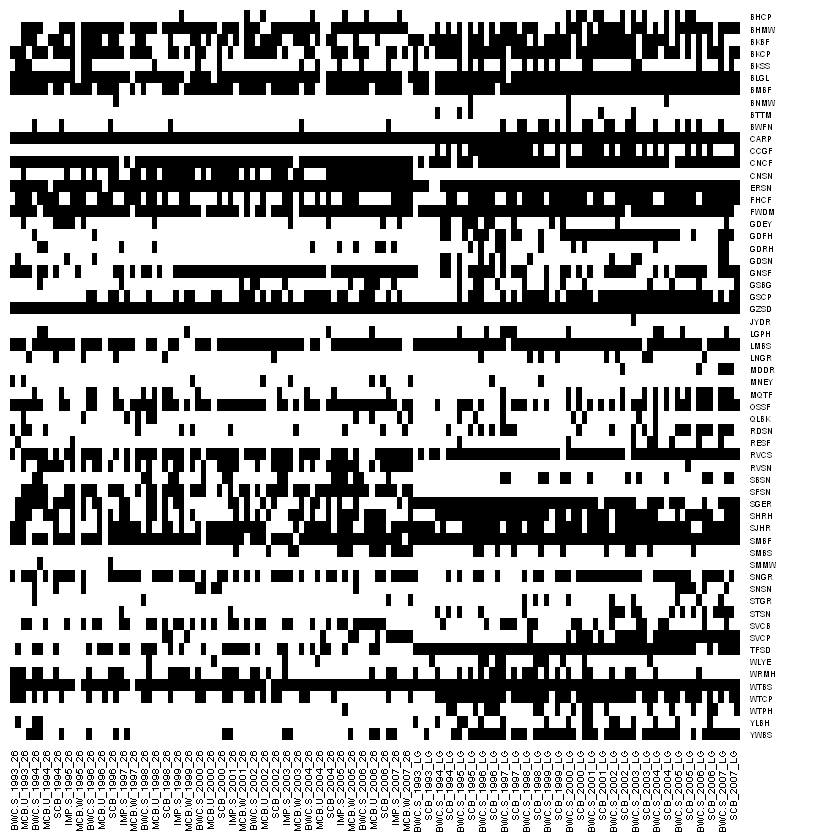

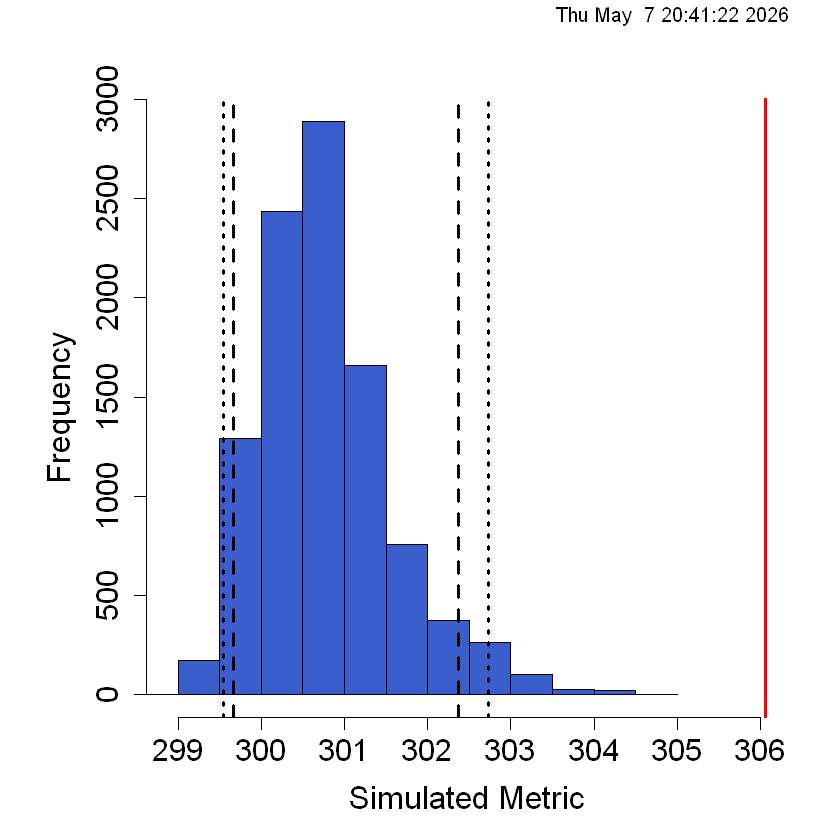

In [152]:
run_ecosim(pool="both", breakpoint="<=2007")

## > 2007

[1]  61 152
     BWC.S_2008_26 IMP.S_2008_26 MCB.U_2008_26 MCB.W_2008_26 SCB_2008_26
BHCP             0             0             0             0           0
BHMW             1             1             0             0           0
BKBF             1             1             1             0           1
BKCP             0             1             1             1           0
BKSS             1             0             1             0           1
Species: 61 
Sites: 152 
Total presences: 4081 
Fill percent: 0.44 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:41:41 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  18 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  365.29 
Mean Of Simulated Index:  354.69 
Variance Of Simulated Index:  0.98501 
Lower 95% (1-tail):  353.16 
Upper 95% (1-tail):  

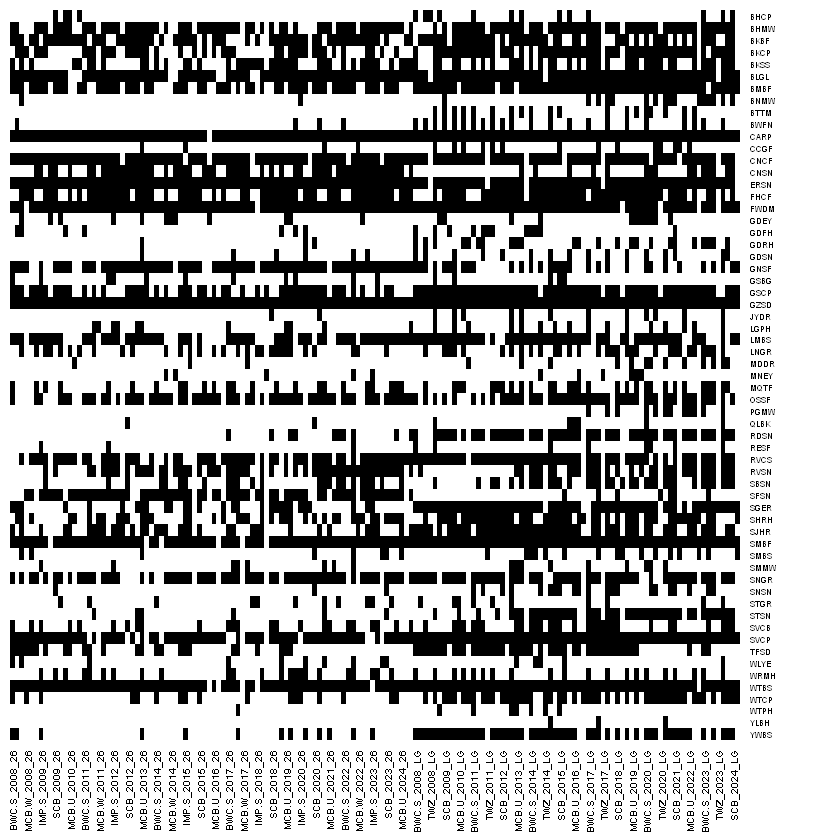

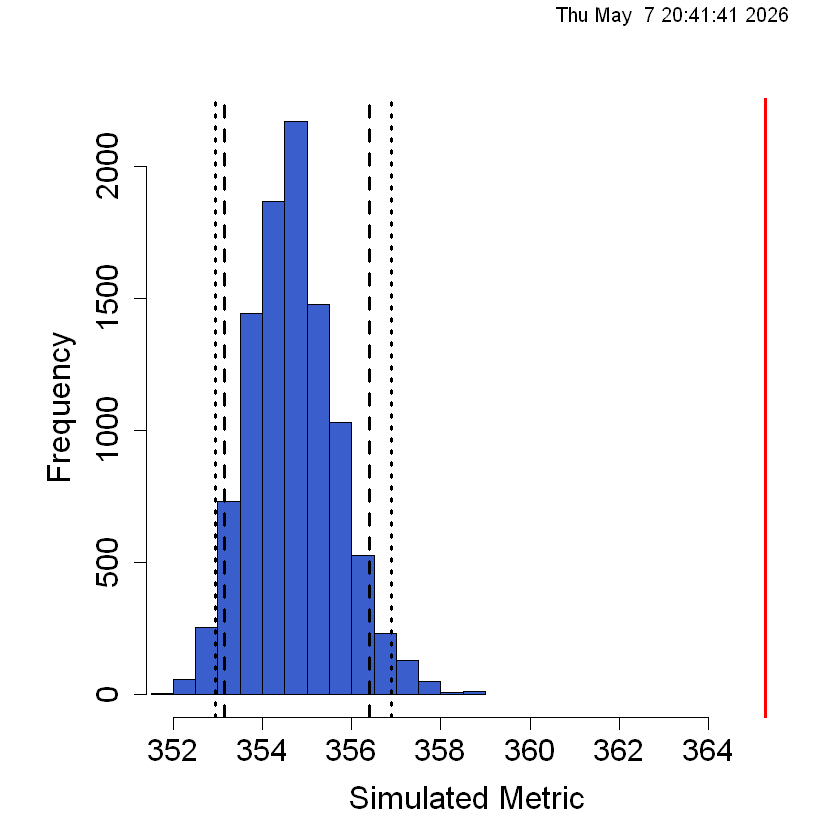

In [153]:
run_ecosim(pool="both", breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

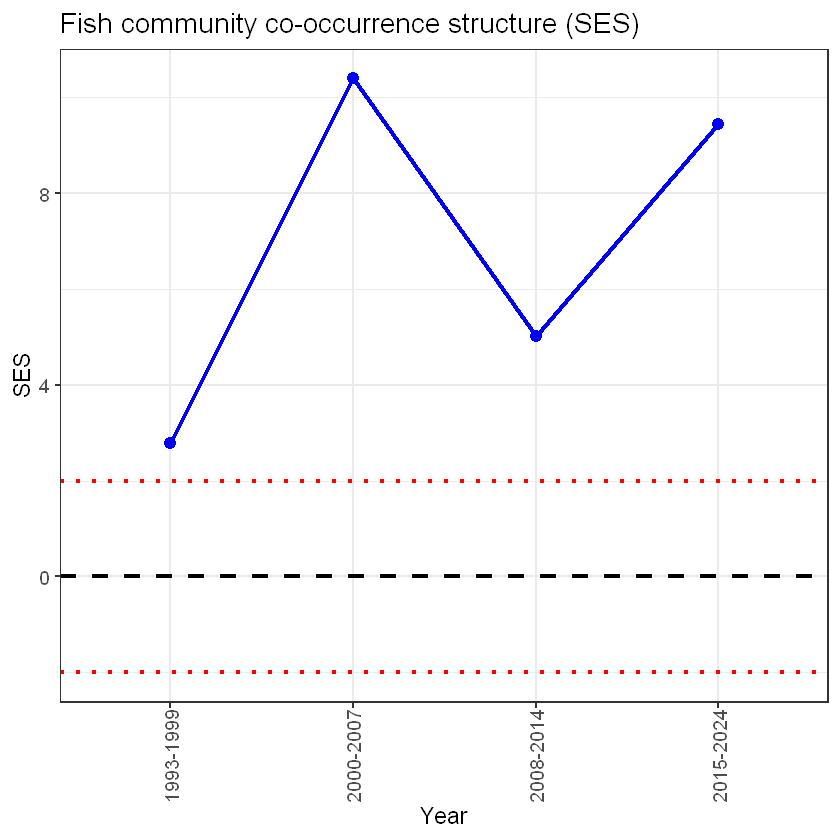

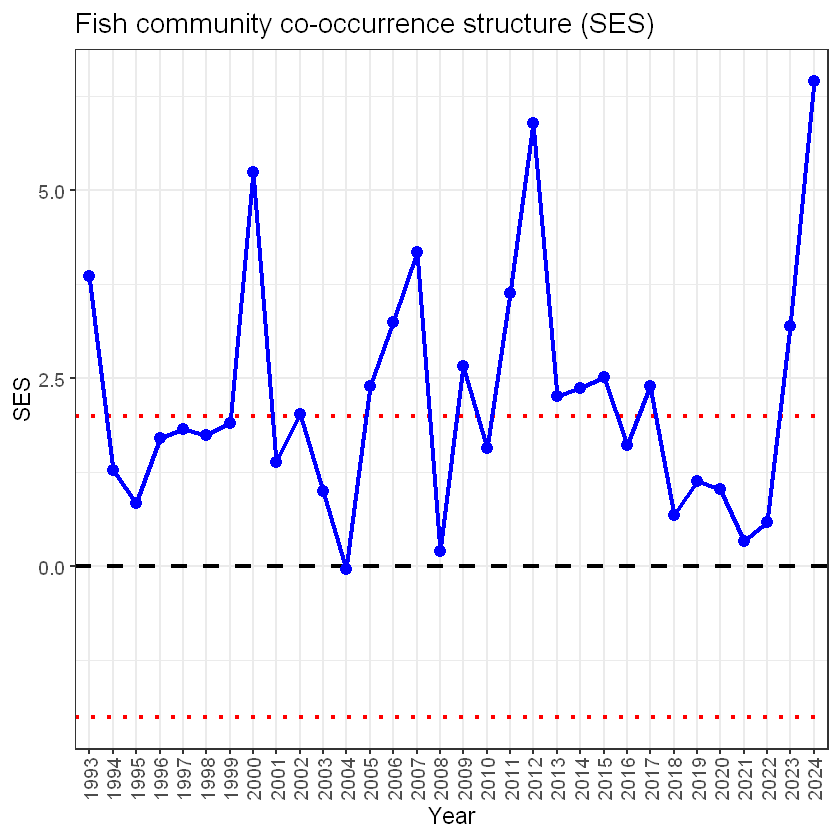

In [154]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool="both", year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool="both", year_chunks)


# Pool 26

## <= 2007

[1] 56 74
     BWC.S_1993_26 IMP.S_1993_26 MCB.U_1993_26 SCB_1993_26 BWC.S_1994_26
BHCP             0             0             0           0             0
BHMW             0             0             1           1             1
BKBF             0             0             1           1             1
BKCP             1             1             1           0             1
BKSS             0             1             1           1             0
Species: 56 
Sites: 74 
Total presences: 1670 
Fill percent: 0.4 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:49:59 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  29 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  83.81 
Mean Of Simulated Index:  83.203 
Variance Of Simulated Index:  0.082879 
Lower 95% (1-tail):  82.745 
Upper 95% (1-tail):  83.6

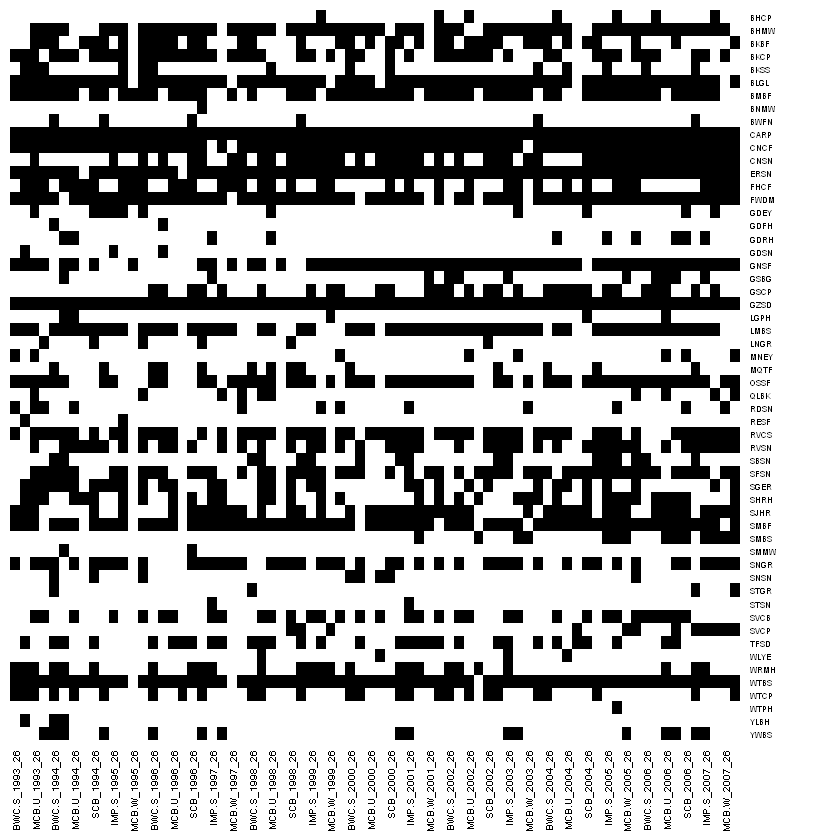

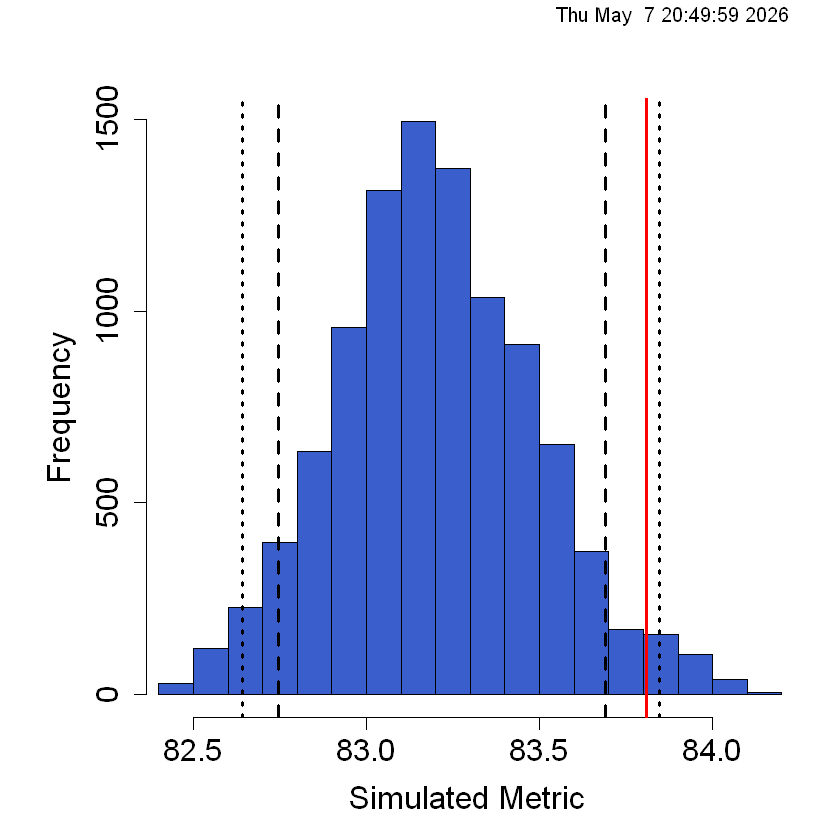

In [155]:
run_ecosim(pool=26, breakpoint="<=2007")

## > 2007

[1] 58 84
     BWC.S_2008_26 IMP.S_2008_26 MCB.U_2008_26 MCB.W_2008_26 SCB_2008_26
BHCP             0             0             0             0           0
BHMW             1             1             0             0           0
BKBF             1             1             1             0           1
BKCP             0             1             1             1           0
BKSS             1             0             1             0           1
Species: 58 
Sites: 84 
Total presences: 1981 
Fill percent: 0.41 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:50:15 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  15 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  91.094 
Mean Of Simulated Index:  89.658 
Variance Of Simulated Index:  0.12135 
Lower 95% (1-tail):  89.111 
Upper 95% (1-tail):  90.

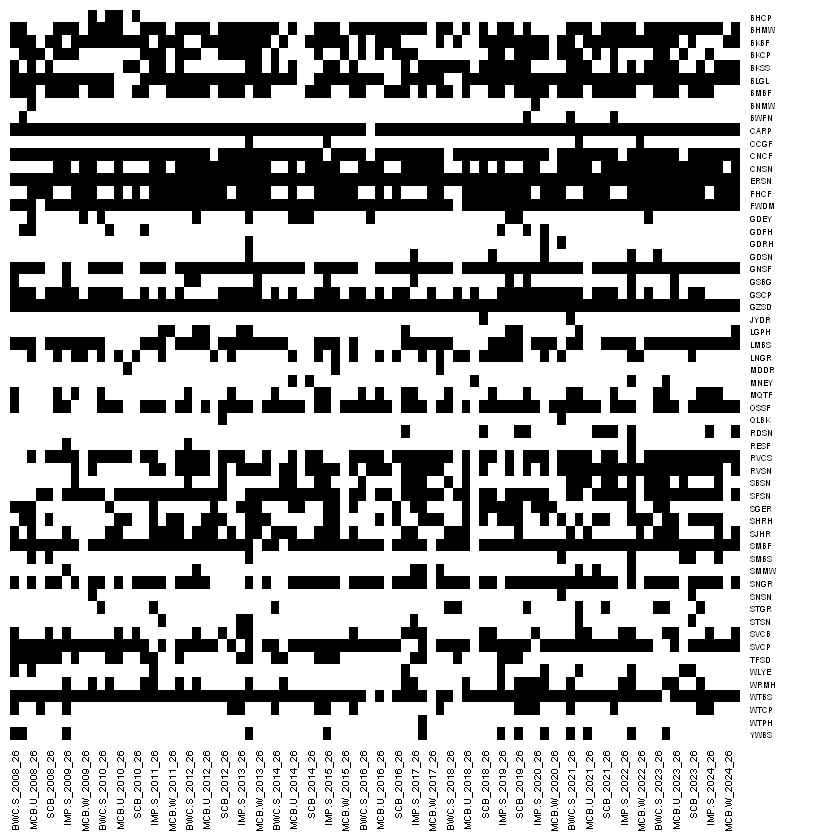

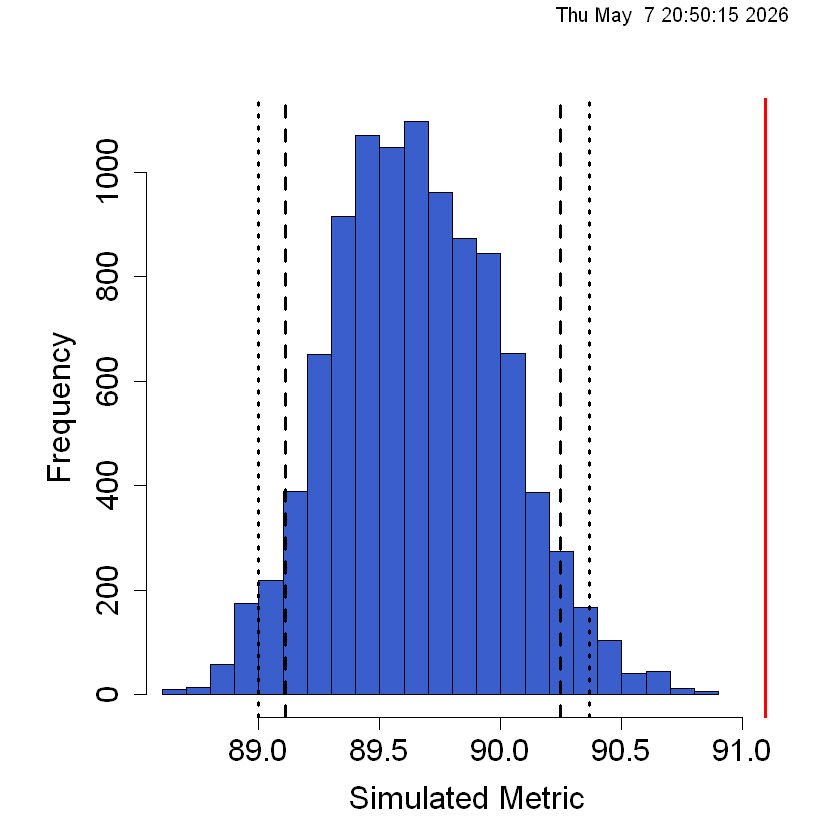

In [156]:
run_ecosim(pool=26, breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

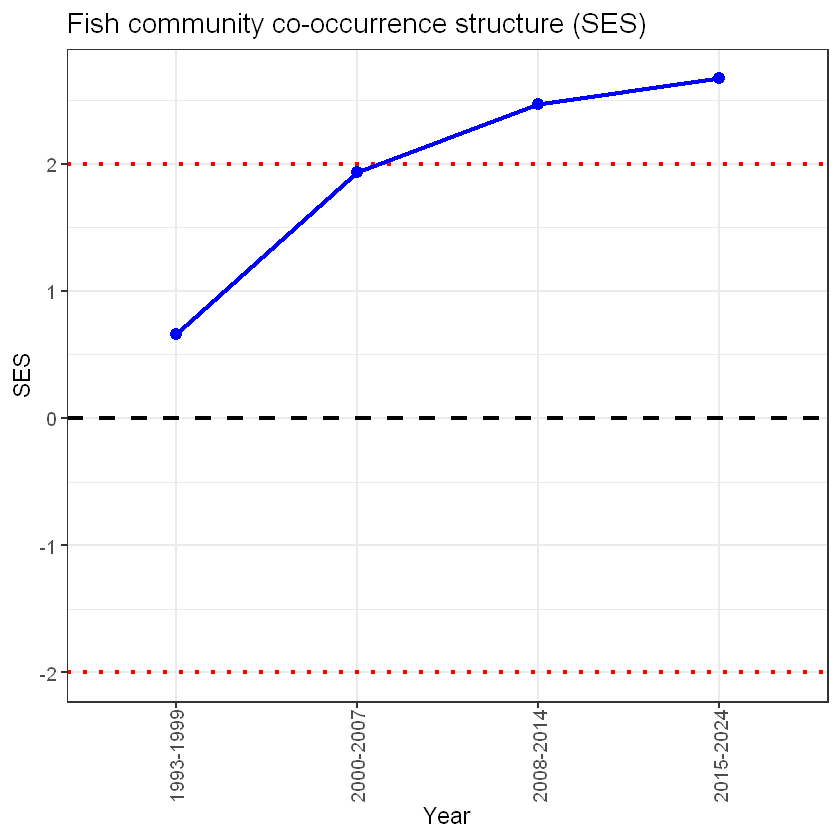

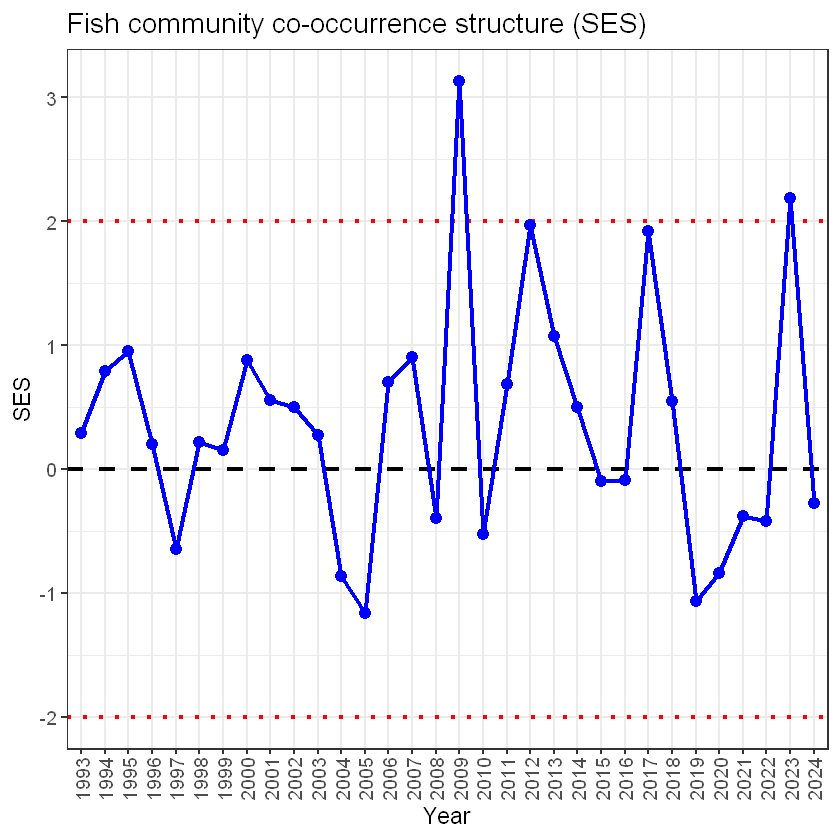

In [157]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool=26, year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool=26, year_chunks)


# La Grange

## <= 2007

[1] 57 60
     BWC.S_1993_LG MCB.U_1993_LG SCB_1993_LG TWZ_1993_LG BWC.S_1994_LG
BHCP             0             0           0           0             0
BHMW             0             0           0           0             1
BKBF             1             1           0           1             1
BKCP             1             0           1           0             1
BKSS             1             0           0           0             0
Species: 57 
Sites: 60 
Total presences: 1670 
Fill percent: 0.49 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:55:18 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  21 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  54.88 
Mean Of Simulated Index:  53.728 
Variance Of Simulated Index:  0.066108 
Lower 95% (1-tail):  53.328 
Upper 95% (1-tail):  54.157 
Lower 9

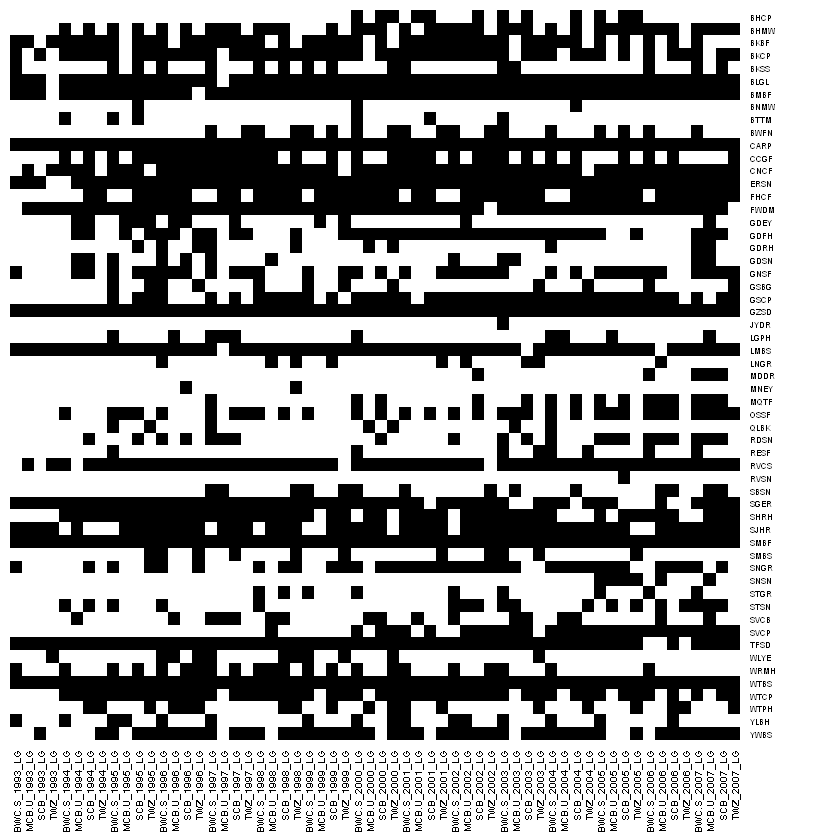

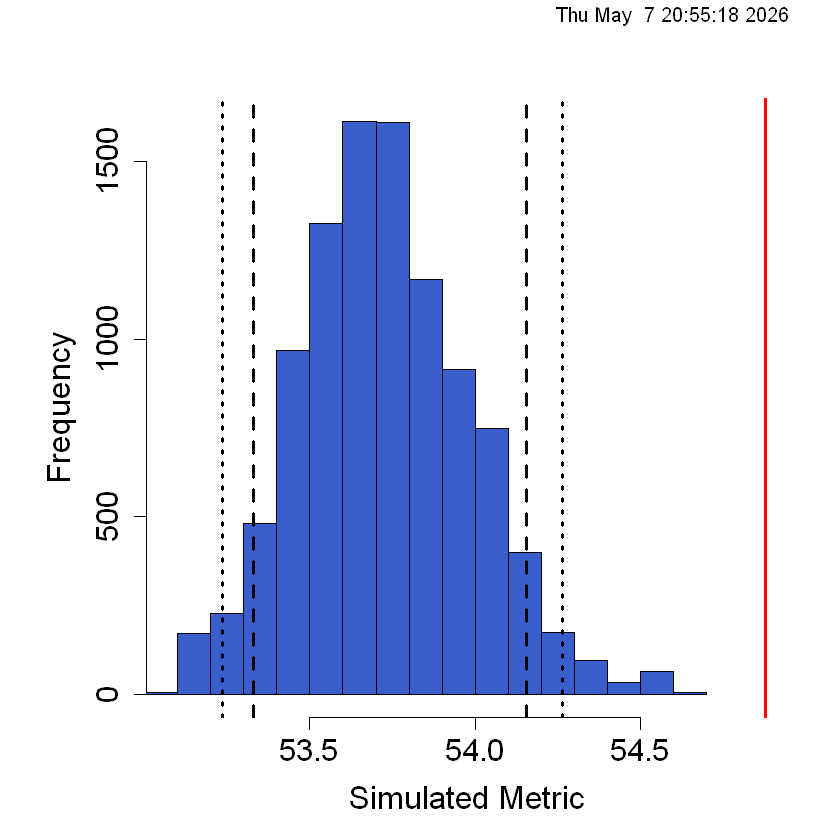

In [158]:
run_ecosim(pool="LG", breakpoint="<=2007")

## > 2007

[1] 61 68
     BWC.S_2008_LG MCB.U_2008_LG SCB_2008_LG TWZ_2008_LG BWC.S_2009_LG
BHCP             1             0           1           1             0
BHMW             0             0           0           0             1
BKBF             0             1           1           1             1
BKCP             1             0           0           0             1
BKSS             1             0           0           0             1
Species: 61 
Sites: 68 
Total presences: 2100 
Fill percent: 0.51 
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
Time Stamp:  Thu May  7 20:55:35 2026 
Reproducible:  
Number of Replications:  
Elapsed Time:  17 secs 
Metric:  c_score 
Algorithm:  sim9 
Observed Index:  67.515 
Mean Of Simulated Index:  65.552 
Variance Of Simulated Index:  0.078164 
Lower 95% (1-tail):  65.095 
Upper 95% (1-tail):  66.03 
Lower 9

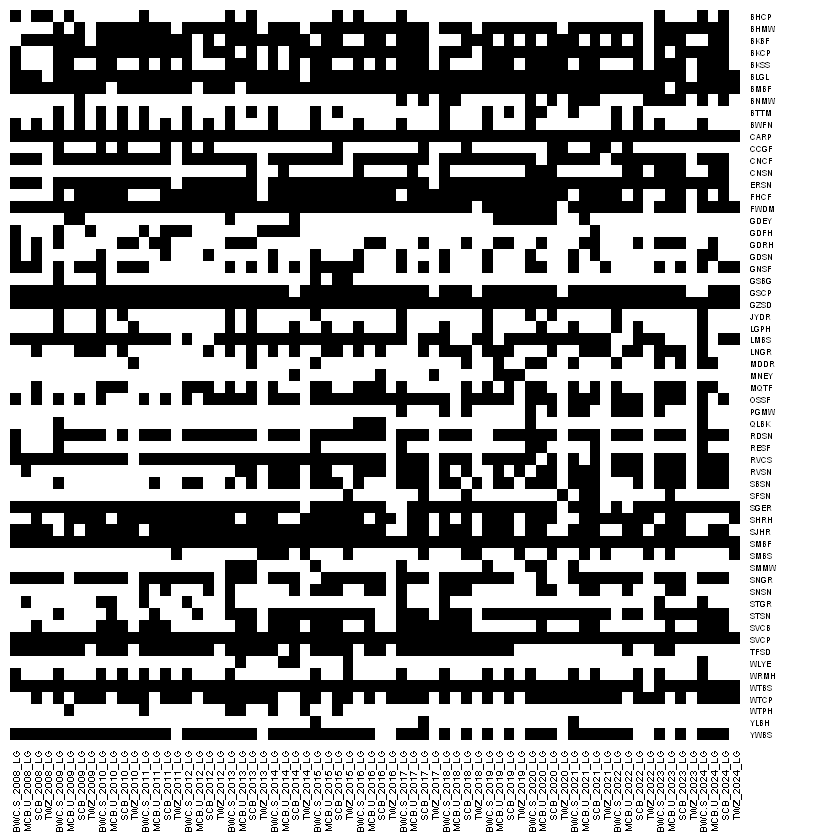

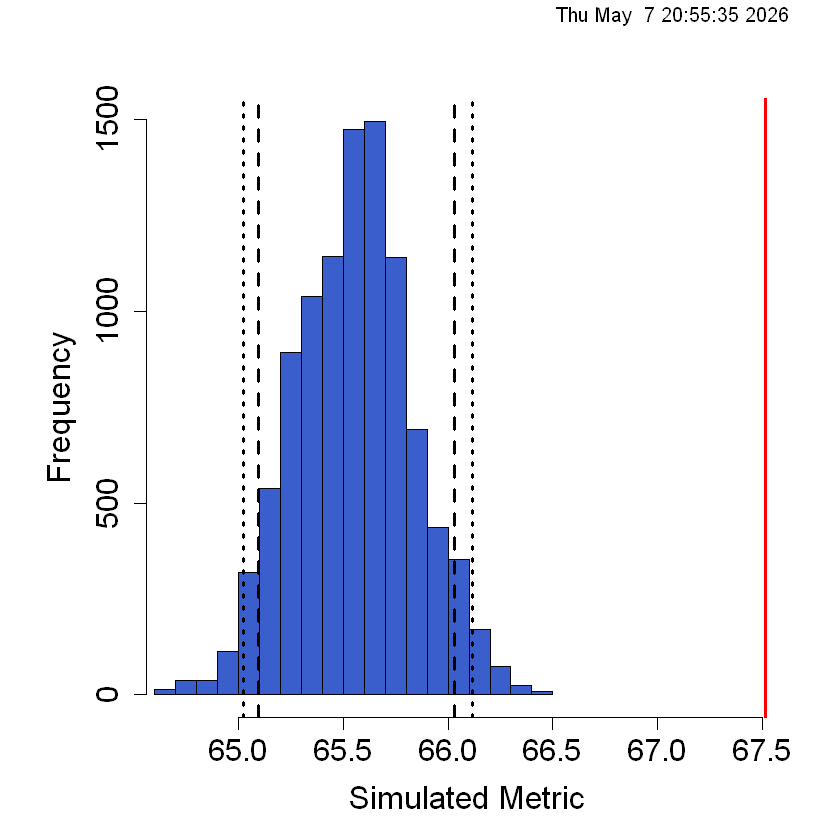

In [159]:
run_ecosim(pool="LG", breakpoint=">2007")

## SES year chunks

[1] "Running years: 1993-1999"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2000-2007"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2008-2014"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 2015-2024"
Burn-in Progress 
  |======================================================================| 100%
Swap Progress 
  |======================================================================| 100%
[1] "Running years: 1993-1993"
Burn-in Progress 
  |====================================================

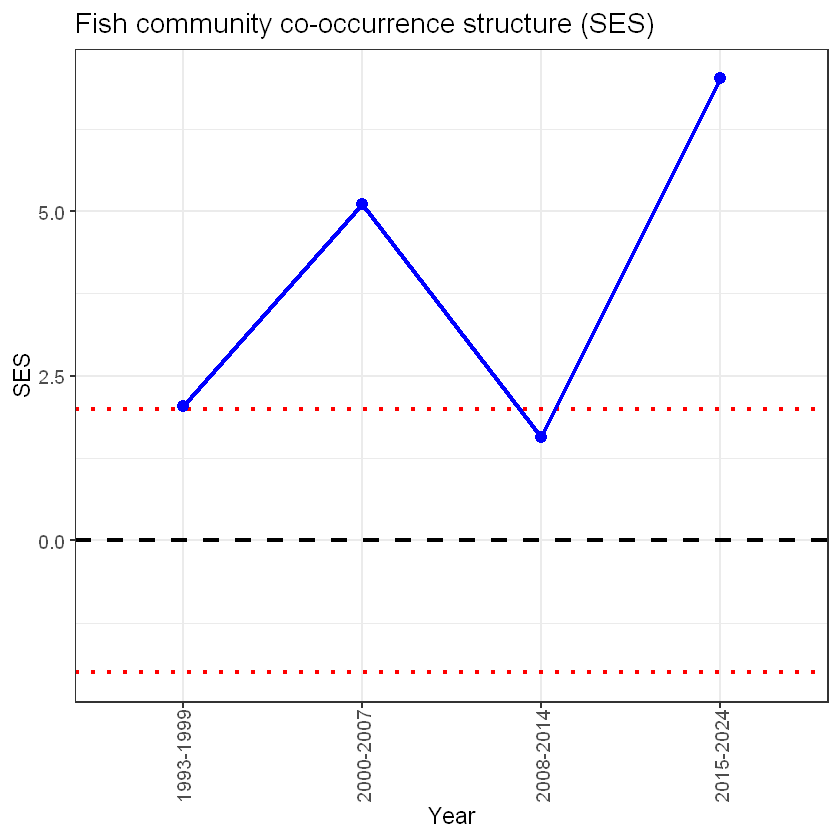

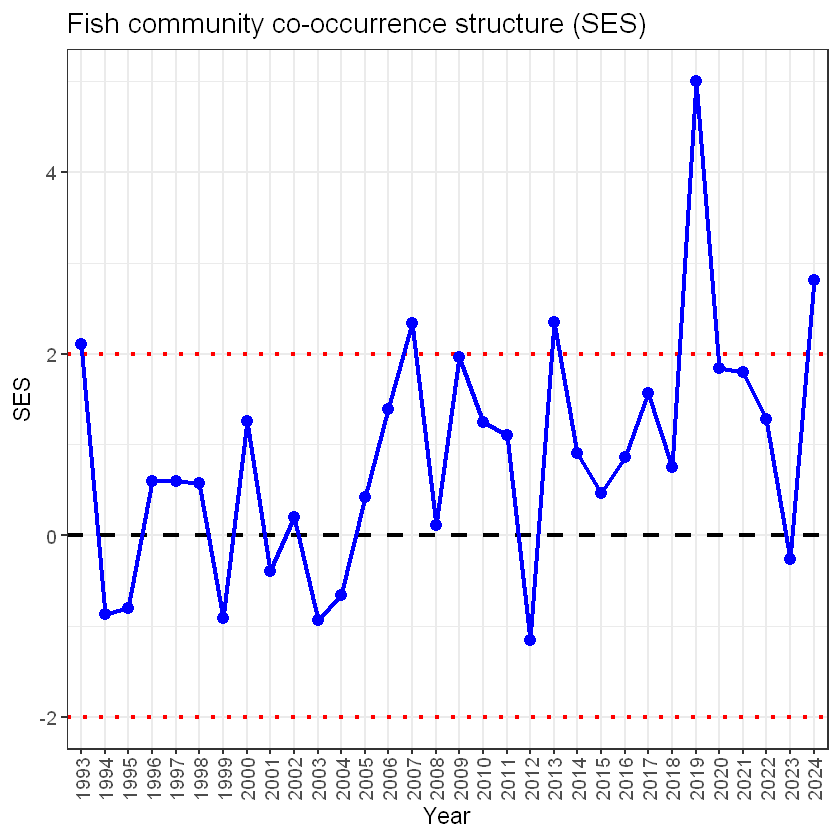

In [160]:
year_chunks <- list(1993:1999, 2000:2007, 2008:2014, 2015:2024)
run_ecosim_loop(pool="LG", year_chunks) 

year_chunks <- c(1993:2024)
run_ecosim_loop(pool="LG", year_chunks)
